# Assignment 1

This assignment covers material from Weeks 1–4. Think of it as a spot-check: five exercises that test important analytical and visualization skills from the first part of the course.

## Formalia:

<mark>Please read the **[assignment overview page](https://github.com/suneman/socialdata2026/wiki/Assignments)** carefully before proceeding.</mark> This page contains information about formatting (including formats etc.), group sizes, and many other aspects of handing in the assignment. 

***If you fail to follow these simple instructions, it will negatively impact your grade!***

**Due date and time**: The assignment is due on Monday March 2nd, 2026 at 23:55. Hand in your files via DTU Learn. 

## Important Notes:
**All exercises use your combined SF crime dataset** (2003–present) that you built during Week 2, along with your Personal Focus Crimes. Make sure you have those ready before you start.
* **Hint**: The number of focus crimes are up to you, but choosing very few focus-crimes (1-5, let's say) feels like taking the easy way out to me, so to get top marks, you'll need 8 or more focus crimes (but it's not that more are better, 16 isn't necessarily better than 8).

Each assignment draws directly on the weekly exercises - you should be able to pull your work directly from there.

<div class="alert alert-block alert-info">
The same LLM guidance applies here as during the weekly exercises: use your LLM freely for coding, pandas syntax, and plot formatting. Do not use it for interpretation, reflection, or anything that asks for your own thinking. 
<br>  <br>
If you use and LLM to cheat, you are missing out on your education ... it will mean that you're not getting all you can out of this class ... and, more importantly, that you are literally wasting this crucial time of your DTU-journey, designed to make you smarter and ready for the world.
</div>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

merged_df = pd.read_csv("../data/sf_crime_merged.csv")

merged_df["Incident Date"] = pd.to_datetime(merged_df["Incident Date"])
merged_df = merged_df[merged_df["Incident Date"].dt.year <= 2025]

print("Size of the dataset:", len(merged_df))
print("Columns in the dataset:", merged_df.columns.tolist())

Size of the dataset: 1769353
Columns in the dataset: ['Unified Category', 'Incident Date', 'Incident Time', 'Police District', 'Incident Code', 'Incident Number', 'Incident Description', 'Latitude', 'Longitude', 'Resolution', 'Source']


In [2]:
# Selected focus crimes with a high accuracy
personal_focus_crimes = [
    "Assault",
    "Burglary",
    "Robbery",
    "Larceny Theft",
    "Motor Vehicle Theft",
    "Fraud",
    "Arson",
    "Forgery And Counterfeiting",
    "Stolen Property",
    "Embezzlement",
    "Prostitution",
    "Missing Person",
    "Warrant",
    "Liquor Laws",
    "Disorderly Conduct",
]
# Filter dataset to personal focus crimes only
focus_df = merged_df[merged_df["Unified Category"].isin(personal_focus_crimes)].copy()
focus_df = focus_df.dropna(subset=["Police District"])
# Normalize district names (the merged data uses both ALL CAPS and Title Case)
focus_df["Police District"] = focus_df["Police District"].str.title()

---
## Assignment 1.1: Temporal Overview

Let's start by getting the big picture of how crime has changed over the full 20+ year period covered by your combined dataset.

*Draws from*: Week 1, Exercises 4.1 and 4.2 — applied here to the full merged dataset (2003–present) rather than just 2018–present.

> * Using your combined dataset (2003–present), plot the total number of incidents **per year** for each of your Personal Focus Crimes. Display at least the years 2003–2025. 
> * Make sure your plot follows good visualization practices: labeled axes, a legend, a descriptive title.
> * Identify and comment on at least two notable features in the plot — for example, long-term trends, sudden drops or spikes, or the impact of COVID-19 in 2020. For each feature, offer a possible explanation.

Year with most incidents:   2017 (89,419)
Year with fewest incidents: 2025 (51,381)


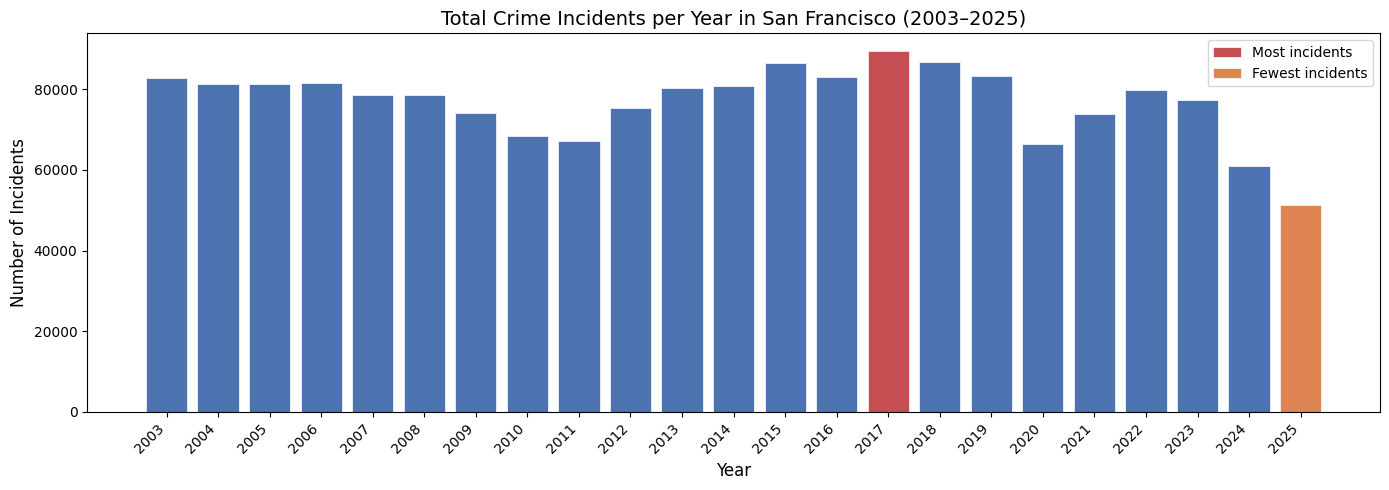

In [3]:
merged_df["Year"] = merged_df["Incident Date"].dt.year

yearly_counts = merged_df.groupby("Year").size()

print(f"Year with most incidents:   {yearly_counts.idxmax()} ({yearly_counts.max():,})")
print(f"Year with fewest incidents: {yearly_counts.idxmin()} ({yearly_counts.min():,})")

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(yearly_counts.index, yearly_counts.values,
              color="#4c72b0", edgecolor="white", linewidth=0.5)

ax.bar(yearly_counts.idxmax(), yearly_counts.max(), color="#c44e52",
       edgecolor="white", linewidth=0.5, label="Most incidents")
ax.bar(yearly_counts.idxmin(), yearly_counts.min(), color="#dd8452",
       edgecolor="white", linewidth=0.5, label="Fewest incidents")

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Number of Incidents", fontsize=12)
ax.set_title("Total Crime Incidents per Year in San Francisco (2003–2025)", fontsize=14)
ax.set_xticks(yearly_counts.index)
ax.set_xticklabels(yearly_counts.index.astype(int), rotation=45, ha="right")
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

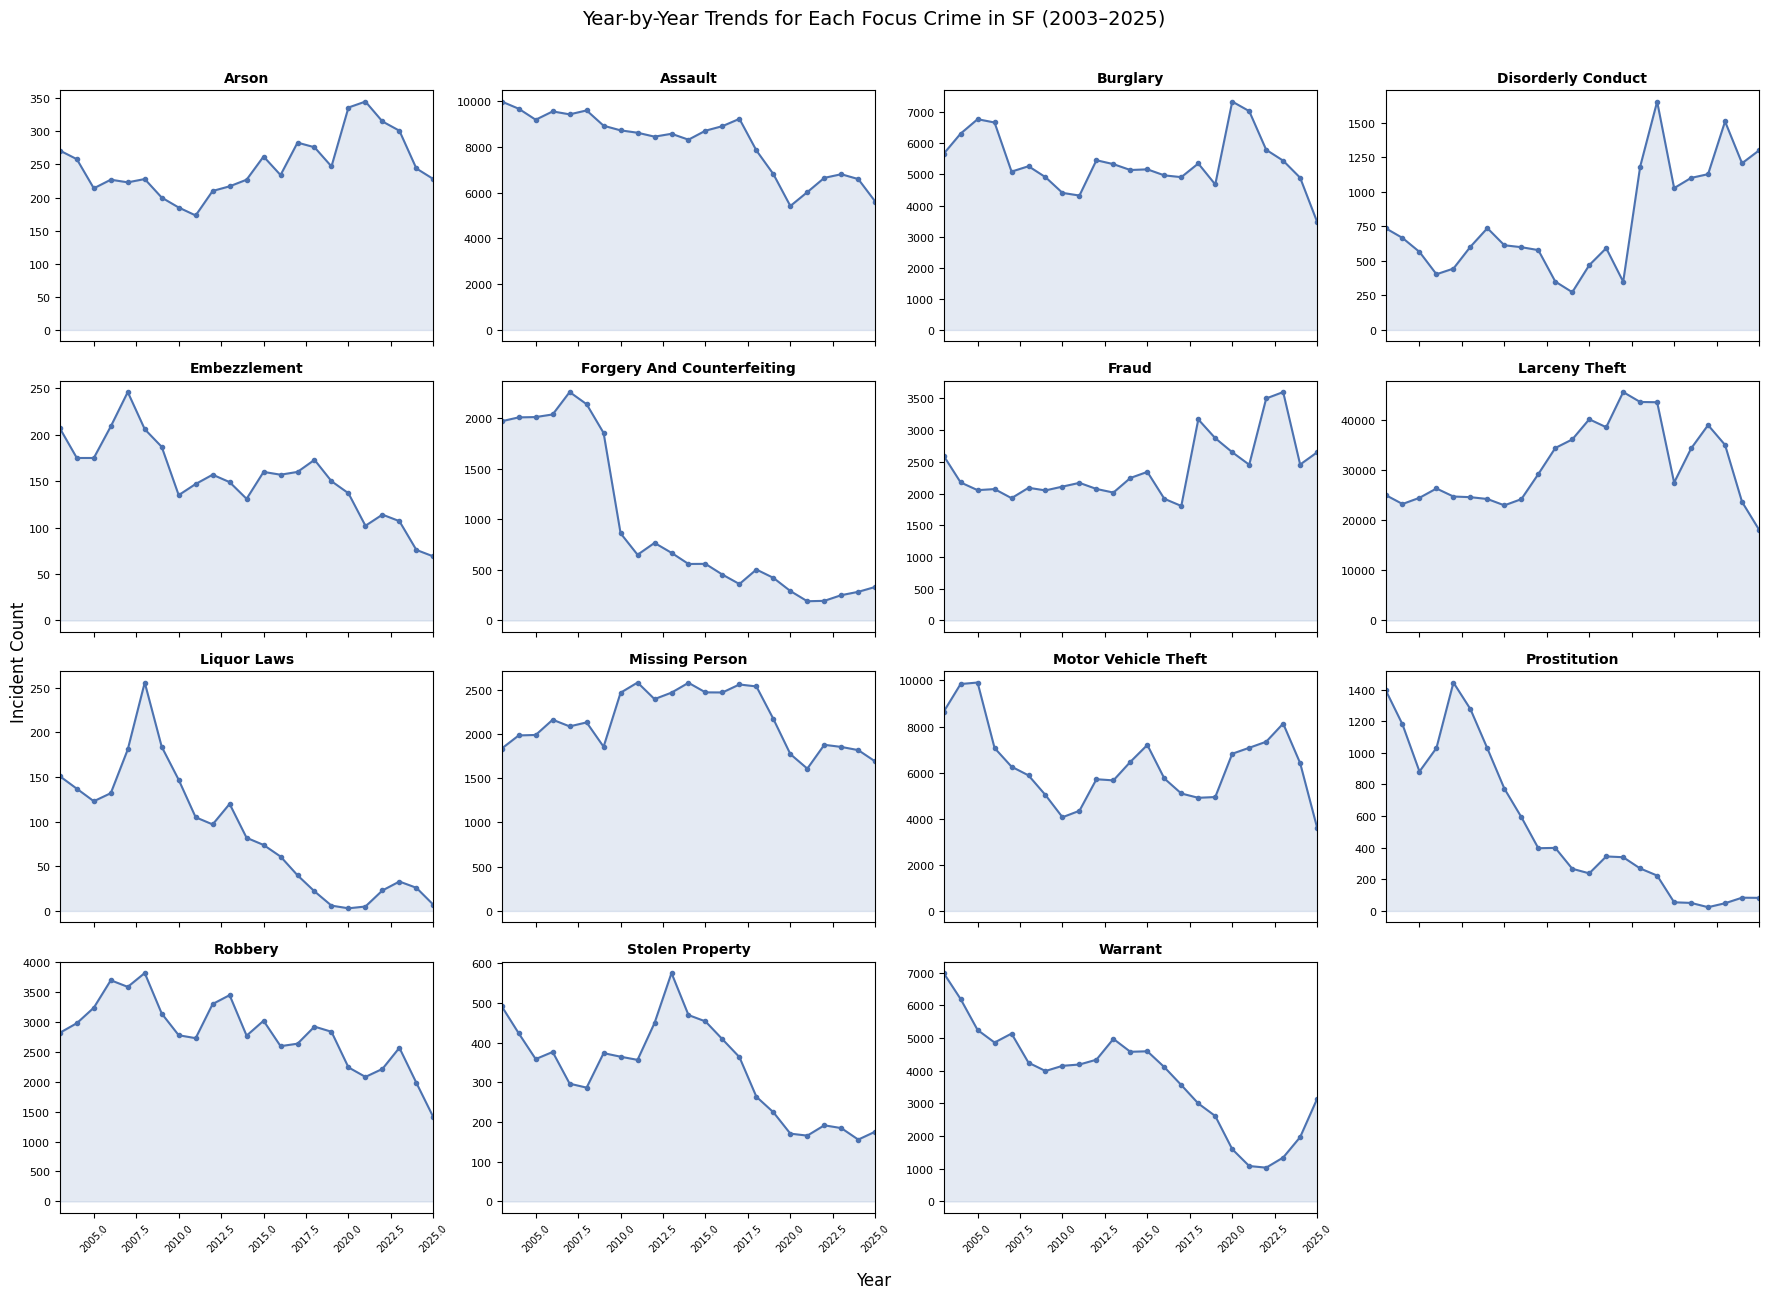

In [4]:
focus_df["Incident Date"] = pd.to_datetime(focus_df["Incident Date"], errors="coerce")
focus_df["Year"] = focus_df["Incident Date"].dt.year

sorted_crimes = sorted(personal_focus_crimes)
ncols = 4
nrows = -(-len(sorted_crimes) // ncols)  # ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3.2), sharex=True)
axes = axes.flatten()

for i, crime in enumerate(sorted_crimes):
    ax = axes[i]
    crime_yearly = (
        focus_df[focus_df["Unified Category"] == crime]
        .groupby("Year")
        .size()
        .reindex(range(2003, 2026), fill_value=0)
    )
    ax.plot(crime_yearly.index, crime_yearly.values,
            marker="o", markersize=3, linewidth=1.5, color="#4c72b0")
    ax.fill_between(crime_yearly.index, crime_yearly.values, alpha=0.15, color="#4c72b0")
    ax.set_title(crime, fontsize=10, fontweight="bold")
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.tick_params(axis="y", labelsize=8)
    ax.set_xlim(2003, 2025)

for j in range(len(sorted_crimes), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Year-by-Year Trends for Each Focus Crime in SF (2003–2025)",
             fontsize=14, y=1.01)
fig.supxlabel("Year", fontsize=12)
fig.supylabel("Incident Count", fontsize=12)

plt.tight_layout()
plt.show()

**Notable features:**

**COVID-19 impact (2020):** Total incidents drop around 2020. Lockdowns, remote work, and reduced amount of poeple outsid led to fewer opportunities for property crimes (e.g., Larceny Theft, Robbery) and less public interaction overall. Yet, bulglary significanty jumped at the same time.

**Long-term decline (2017 to 2025):** 2017 had the most incidents (around 89k), 2025 the fewest (around 51k). The overall trend after 2017 is downward. Possibly due to the mproved policing, economic changes, or reporting-practice changes. Several focus crimes (e.g., Prostitution, Forgery) show particularly steep declines over the full period.

---
## Assignment 1.2: Crime Profiles by Police District

Different parts of the city have very different crime patterns. Here we quantify that using conditional probabilities.

*Draws from*: Week 3, Exercises 2.1 and 2.2.

> * For each police district in your dataset, compute the **conditional crime profile**: for each of your Personal Focus Crimes, calculate
>
>   $$r(\text{crime}, \text{district}) = \frac{P(\text{crime} \mid \text{district})}{P(\text{crime})}$$
>
>   A value above 1 means that crime type is *over-represented* in that district relative to the city-wide average; below 1 means it is *under-represented*.
> * Visualize these ratios in a way that makes it easy to compare across both districts and crime types. (Simple barcharts are fine, but you may also use ideas from more complex visualization techniques, for example, a heatmap could work well here, but you're free to choose another format if you can justify it.)
> * Pick **one district** whose profile stands out to you. Describe the pattern and offer an explanation for why that district looks the way it does. Are there geographic, demographic, or other factors that might explain it?

SF police districts (10):
Bayview, Central, Ingleside, Mission, Northern, Park, Richmond, Southern, Taraval, Tenderloin

Most total crimes (all categories): Southern  (295,253)
Most Personal Focus Crimes:          Southern  (252,325)
Fewest total crimes:                 Park  (95,733)


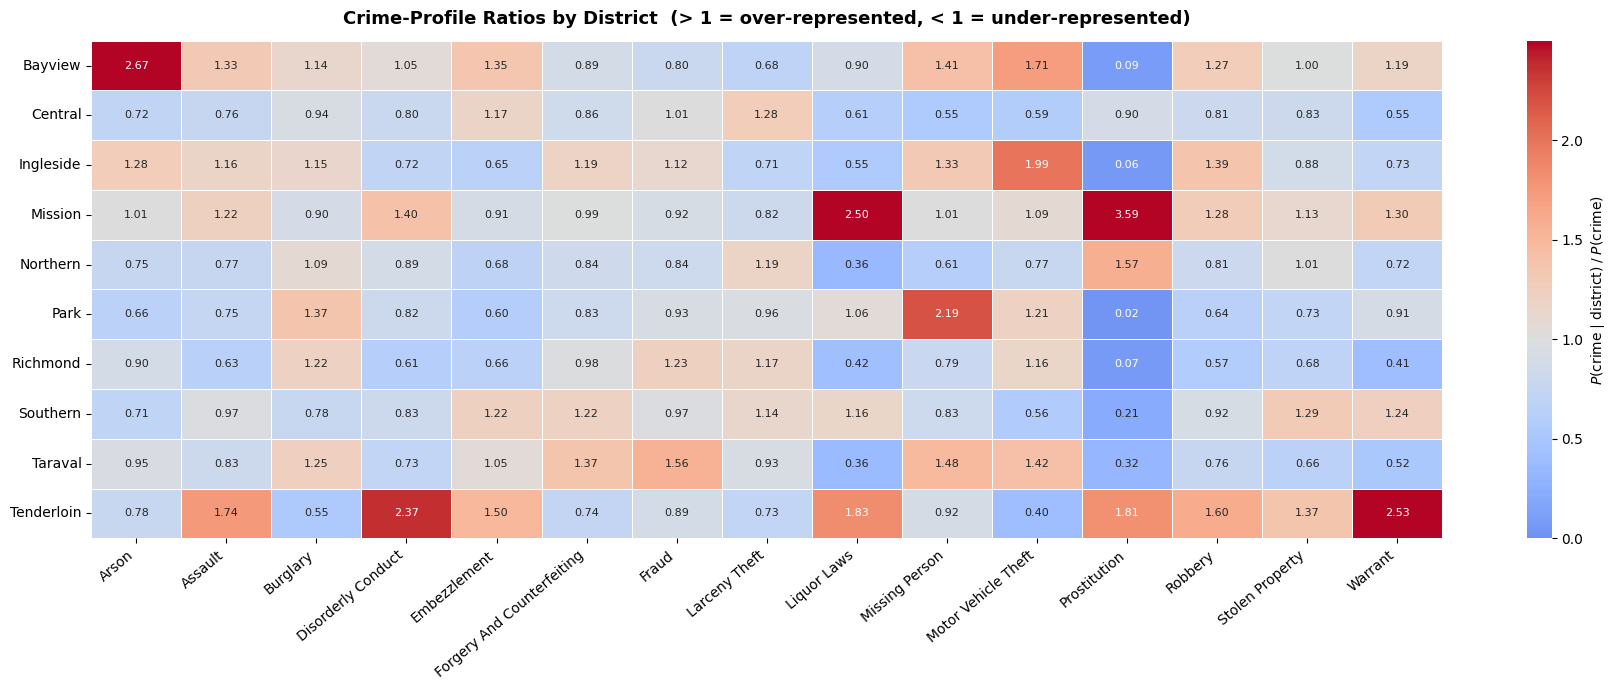


Top 5 over-represented crimes in Tenderloin:
Unified Category
Warrant               2.532
Disorderly Conduct    2.368
Liquor Laws           1.835
Prostitution          1.807
Assault               1.743

Top 5 over-represented crimes in Mission:
Unified Category
Prostitution          3.590
Liquor Laws           2.498
Disorderly Conduct    1.400
Warrant               1.300
Robbery               1.280

Top 5 over-represented crimes in Richmond:
Unified Category
Fraud                         1.226
Burglary                      1.216
Larceny Theft                 1.171
Motor Vehicle Theft           1.161
Forgery And Counterfeiting    0.978

Potentially unstable ratios  (ratio > 2.5 AND < 30 incidents):
  None found — all high ratios are backed by sufficient counts.

Lowest-volume district: Park  (95,733 total crimes)
  Ratio dispersion (std): 0.467
  Median across all districts: 0.427


In [13]:
DISTRICT_COL = "Police District"
CRIME_COL = "Unified Category"

# 10 actual SF districts (exclude "Out Of Sf")
all_df = merged_df.dropna(subset=[DISTRICT_COL]).copy()
all_df[DISTRICT_COL] = all_df[DISTRICT_COL].str.title()
all_df = all_df[all_df[DISTRICT_COL] != "Out Of Sf"]

focus_local = all_df[all_df[CRIME_COL].isin(personal_focus_crimes)].copy()

# ── District listing ──
district_names = sorted(all_df[DISTRICT_COL].unique())
print(f"SF police districts ({len(district_names)}):")
print(", ".join(district_names))

# ── Which district has the most crimes? ──
all_counts = all_df.groupby(DISTRICT_COL).size().sort_values(ascending=False)
focus_counts = focus_local.groupby(DISTRICT_COL).size().sort_values(ascending=False)

print(f"\nMost total crimes (all categories): {all_counts.index[0]}  ({all_counts.iloc[0]:,})")
print(f"Most Personal Focus Crimes:          {focus_counts.index[0]}  ({focus_counts.iloc[0]:,})")
print(f"Fewest total crimes:                 {all_counts.index[-1]}  ({all_counts.iloc[-1]:,})")

# ── P(crime) — city-wide base rate within focus crimes ──
p_crime = focus_local[CRIME_COL].value_counts(normalize=True)

# ── P(crime | district) ──
p_crime_given_district = pd.crosstab(
    focus_local[DISTRICT_COL], focus_local[CRIME_COL], normalize="index"
).reindex(columns=personal_focus_crimes, fill_value=0)

# ── Ratio matrix ──
ratio = p_crime_given_district.div(p_crime, axis=1)

# ── Annotated heatmap ──
fig, ax = plt.subplots(figsize=(18, 7))
sns.heatmap(
    ratio,
    ax=ax,
    cmap="coolwarm",
    center=1.0,
    vmin=0.0,
    vmax=float(np.nanpercentile(ratio.values, 98)),
    linewidths=0.5,
    linecolor="white",
    annot=True,
    fmt=".2f",
    annot_kws={"fontsize": 8},
    cbar_kws={"label": r"$P(\mathrm{crime}\mid\mathrm{district})\;/\;P(\mathrm{crime})$"},
)
ax.set_title(
    "Crime-Profile Ratios by District  (> 1 = over-represented, < 1 = under-represented)",
    fontsize=13, fontweight="bold", pad=12,
)
ax.set_xlabel("")
ax.set_ylabel("")
plt.xticks(rotation=40, ha="right", fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

# ── Top over-represented crimes for key districts ──
for district in ["Tenderloin", "Mission", "Richmond"]:
    top = ratio.loc[district].sort_values(ascending=False).head(5)
    print(f"\nTop 5 over-represented crimes in {district}:")
    print(top.round(3).to_string())

# ── Suspicious extreme ratios (high ratio but few incidents) ──
count_matrix = pd.crosstab(
    focus_local[DISTRICT_COL], focus_local[CRIME_COL]
).reindex(index=ratio.index, columns=ratio.columns, fill_value=0)

flat = ratio.stack().rename("ratio").to_frame().join(count_matrix.stack().rename("count"))
suspicious = flat[(flat["ratio"] > 2.5) & (flat["count"] < 30)].sort_values(
    "ratio", ascending=False
)
print("\nPotentially unstable ratios  (ratio > 2.5 AND < 30 incidents):")
if suspicious.empty:
    print("  None found — all high ratios are backed by sufficient counts.")
else:
    print(suspicious.round(3).to_string())

# ── Lowest-volume district noise check ──
lowest = all_counts.idxmin()
ratio_std = ratio.std(axis=1).sort_values(ascending=False)
print(f"\nLowest-volume district: {lowest}  ({all_counts[lowest]:,} total crimes)")
print(f"  Ratio dispersion (std): {ratio_std[lowest]:.3f}")
print(f"  Median across all districts: {ratio_std.median():.3f}")

**District profile for Tenderloin:** This district stands out as a center for street-level and order-related crimes. Its top crimes are Warrant (2.53), Disorderly Conduct (2.37x), Liquor Laws (1.84x), Prostitution (1.81x), and Assault (1.74x). 

This fits the Tenderloin’s dense urban environment, high foot traffic, nightlife, and concentration of vulnerable populations. Geographic and socioeconomic factors also play a big role here; central location, homelessness, drug-related activity, and a higher density of bars and nightlife. This explain why these offences are over-represented here relative to the city-wide average.

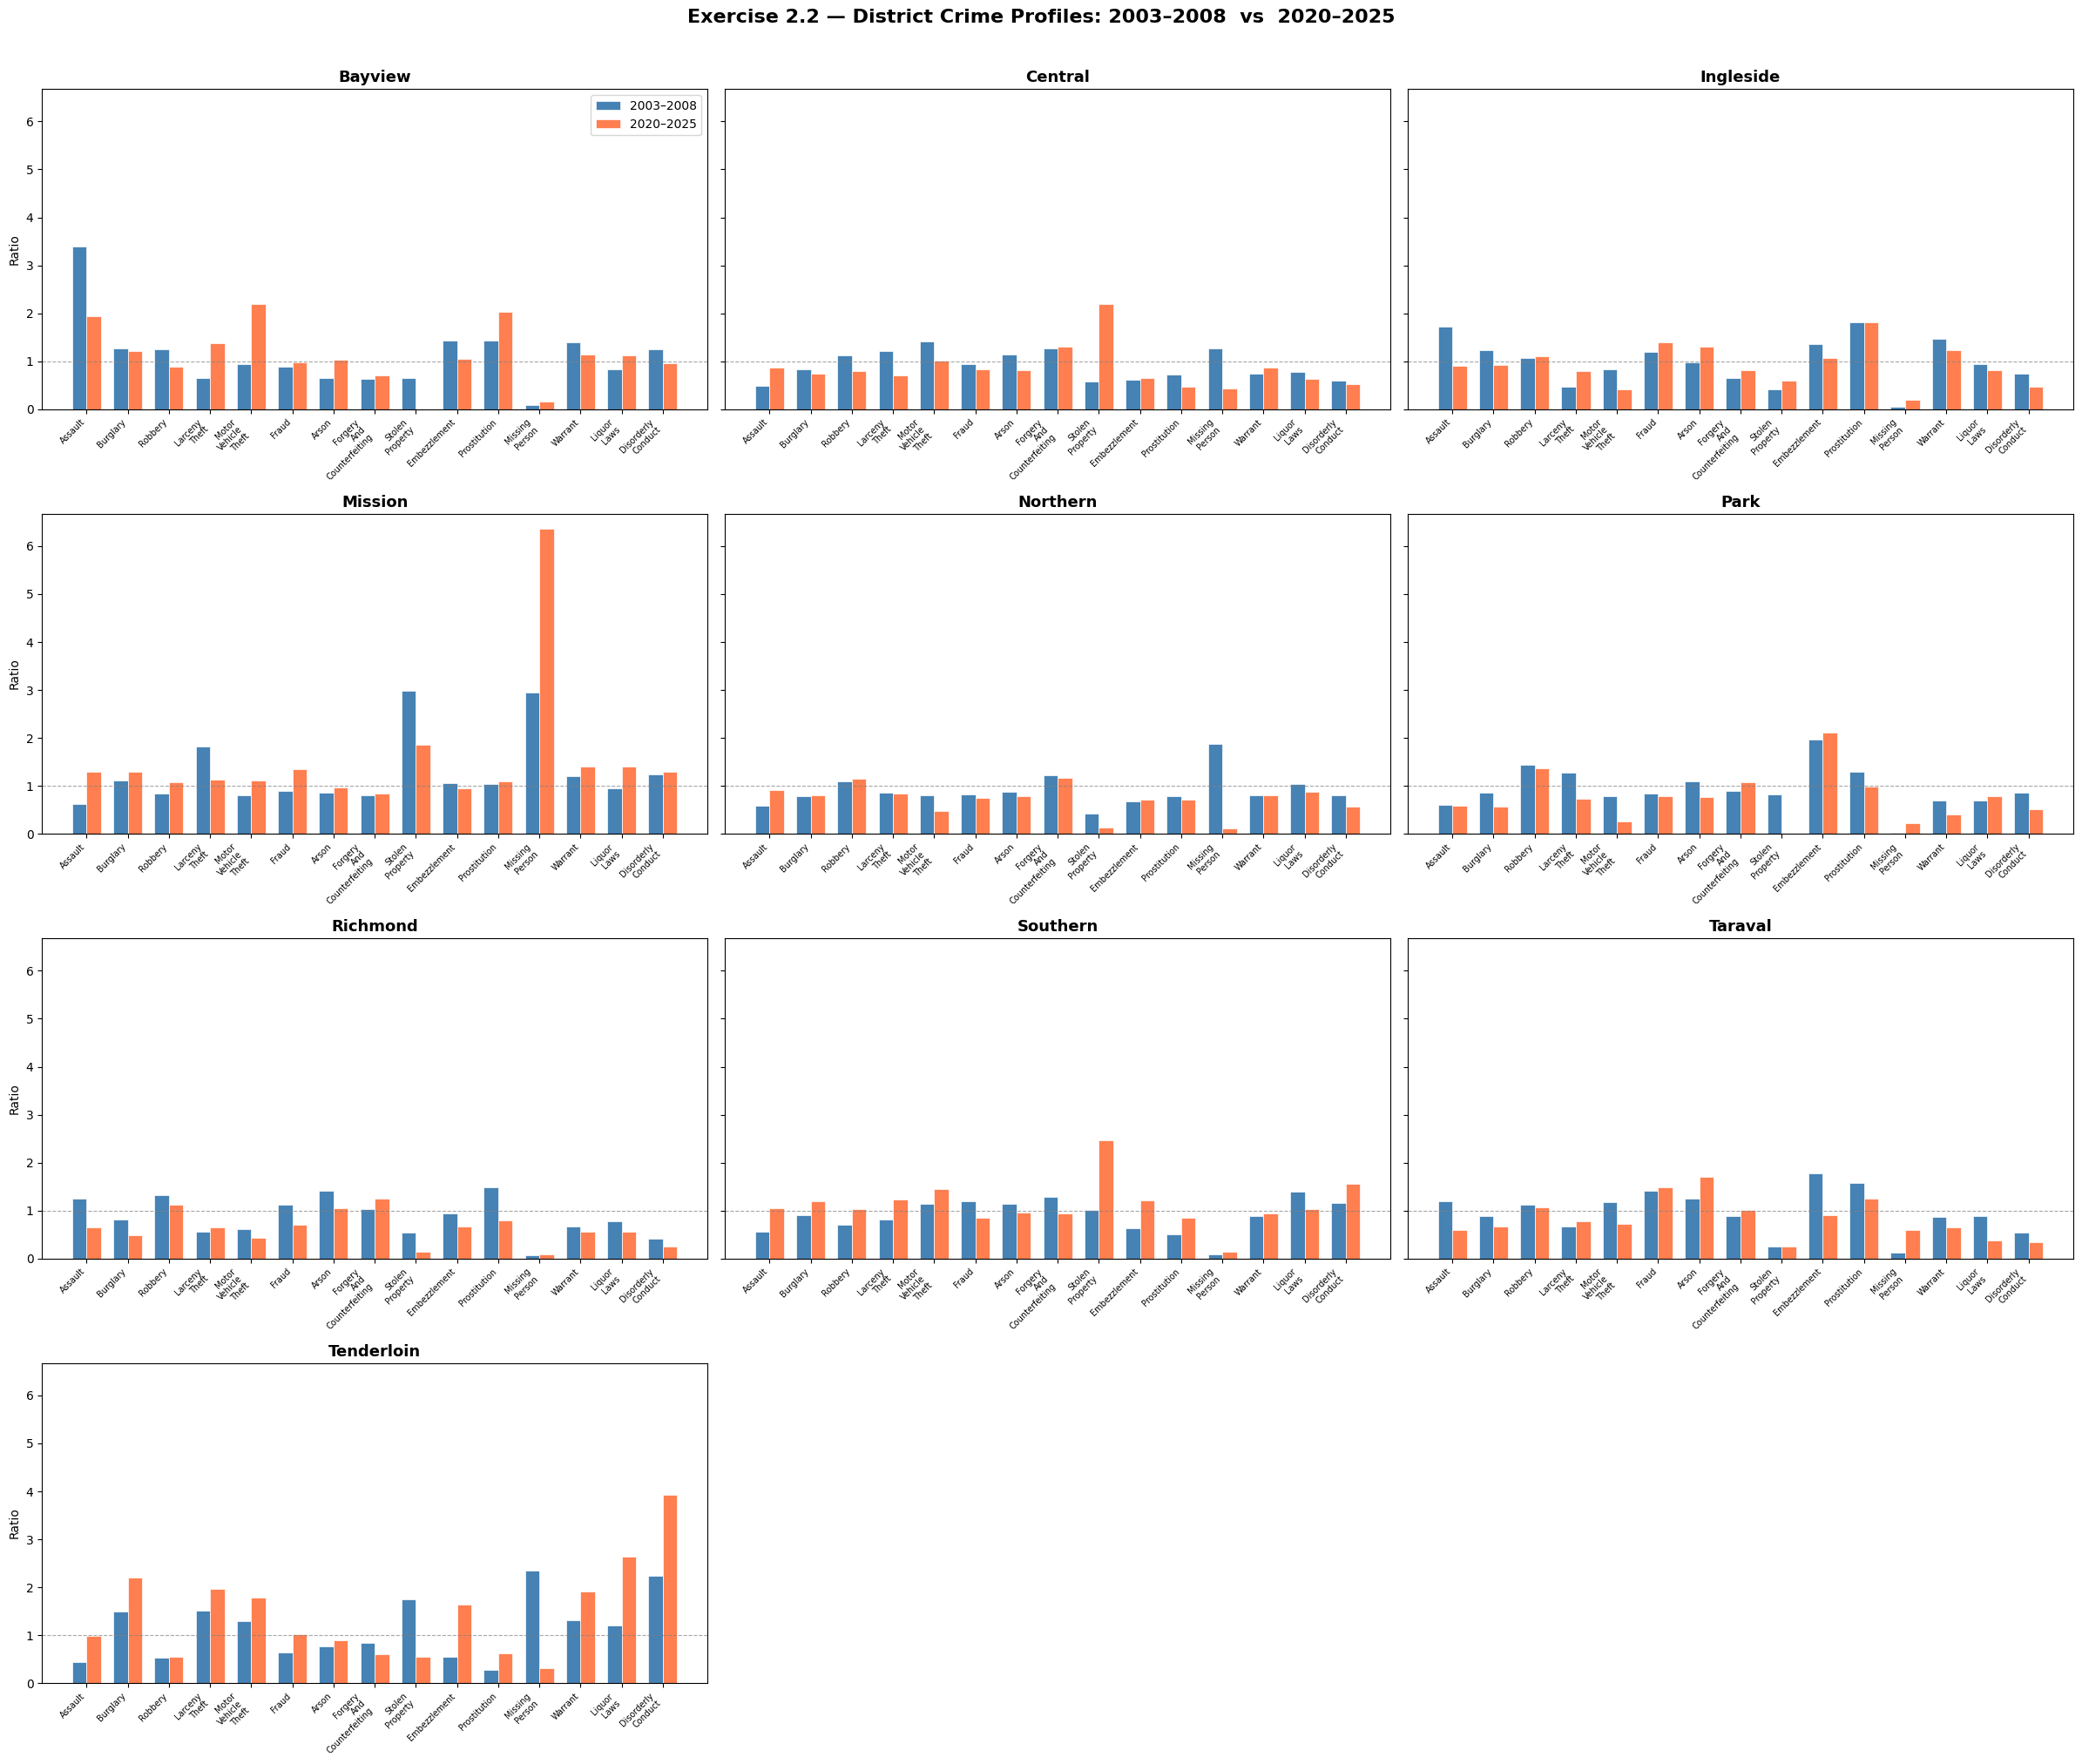

District that changed the most  (L2 distance between ratio vectors):
Police District
Mission       3.814
Tenderloin    3.694
Bayview       2.380
Central       2.067
Southern      1.964
Northern      1.875
Taraval       1.519
Park          1.360
Richmond      1.313
Ingleside     1.229

Crime types with the largest average shift across districts:
Unified Category
Liquor Laws            -0.123
Arson                  -0.107
Stolen Property        +0.073
Warrant                +0.053
Motor Vehicle Theft    -0.034
Burglary               -0.034
Disorderly Conduct     +0.033
Larceny Theft          +0.023


In [6]:
focus_local["Year"] = focus_local["Incident Date"].dt.year


def compute_ratio(subset):
    """P(crime|district) / P(crime) for a time-filtered subset."""
    base = subset[CRIME_COL].value_counts(normalize=True)
    cond = pd.crosstab(
        subset[DISTRICT_COL], subset[CRIME_COL], normalize="index"
    ).reindex(columns=personal_focus_crimes, fill_value=0)
    return cond.div(base, axis=1)


ratio_early = compute_ratio(focus_local[focus_local["Year"].between(2003, 2008)])
ratio_late = compute_ratio(focus_local[focus_local["Year"].between(2020, 2025)])

common_districts = sorted(set(ratio_early.index) & set(ratio_late.index))
ratio_early = ratio_early.loc[common_districts]
ratio_late = ratio_late.loc[common_districts]

# ── Side-by-side grouped bar charts — one subplot per district ──
n_districts = len(common_districts)
ncols = 3
nrows = -(-n_districts // ncols)
crime_labels = [c.replace(" ", "\n") for c in personal_focus_crimes]
x = np.arange(len(personal_focus_crimes))
bar_width = 0.35

fig, axes = plt.subplots(nrows, ncols, figsize=(24, 5 * nrows), sharey=True)
axes_flat = axes.flatten()

for idx, district in enumerate(common_districts):
    ax = axes_flat[idx]
    early_vals = ratio_early.loc[district].values
    late_vals = ratio_late.loc[district].values

    ax.bar(x - bar_width / 2, early_vals, bar_width,
           label="2003–2008", color="steelblue", edgecolor="white", linewidth=0.5)
    ax.bar(x + bar_width / 2, late_vals, bar_width,
           label="2020–2025", color="coral", edgecolor="white", linewidth=0.5)
    ax.axhline(y=1, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)

    ax.set_title(district, fontsize=13, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(crime_labels, fontsize=7, rotation=45, ha="right")
    ax.set_ylabel("Ratio" if idx % ncols == 0 else "")

for j in range(idx + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

axes_flat[0].legend(fontsize=10, loc="upper right")
fig.suptitle(
    "Exercise 2.2 — District Crime Profiles: 2003–2008  vs  2020–2025",
    fontsize=16, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.show()

# ── Quantify "changed the most" via L2 distance between ratio vectors ──
shift_l2 = (
    np.sqrt(((ratio_late - ratio_early) ** 2).sum(axis=1))
    .sort_values(ascending=False)
)
crime_shift = (ratio_late - ratio_early).mean(axis=0)
crime_shift = crime_shift.reindex(crime_shift.abs().sort_values(ascending=False).index)

print("District that changed the most  (L2 distance between ratio vectors):")
print(shift_l2.round(3).to_string())

print("\nCrime types with the largest average shift across districts:")
print(crime_shift.round(3).head(8).map(lambda v: f"{v:+.3f}").to_string())

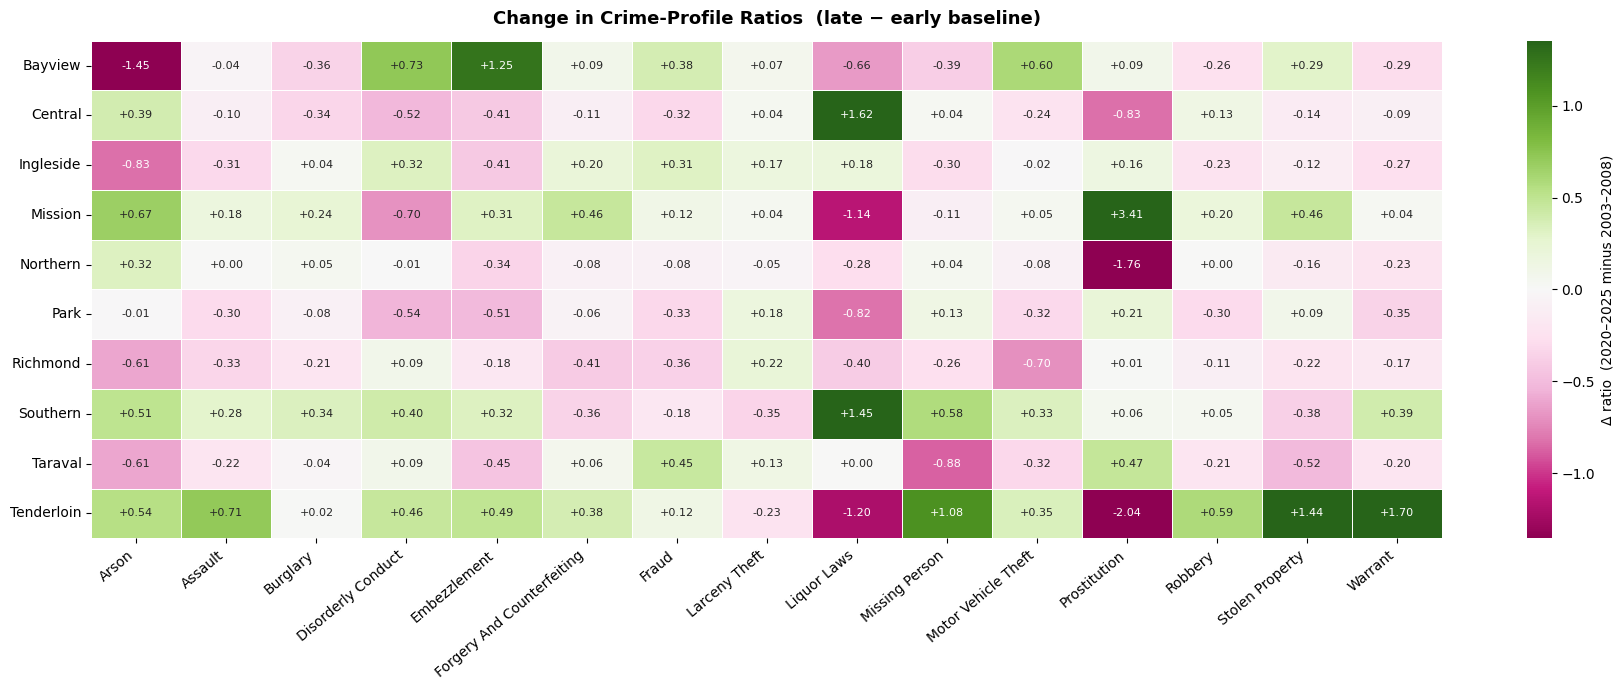

In [7]:
ratio_diff = ratio_late - ratio_early
diff_max = float(np.nanpercentile(np.abs(ratio_diff.values), 95))

fig, ax = plt.subplots(figsize=(18, 7))
sns.heatmap(
    ratio_diff,
    ax=ax,
    cmap="PiYG",
    center=0,
    vmin=-diff_max,
    vmax=diff_max,
    linewidths=0.5,
    linecolor="white",
    annot=True,
    fmt="+.2f",
    annot_kws={"fontsize": 8},
    cbar_kws={"label": "Δ ratio  (2020–2025 minus 2003–2008)"},
)
ax.set_title(
    "Change in Crime-Profile Ratios  (late − early baseline)",
    fontsize=13, fontweight="bold", pad=12,
)
ax.set_xlabel("")
ax.set_ylabel("")
plt.xticks(rotation=40, ha="right", fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

**How profiles changed over time:** Mission and Tenderloin show the largest L2 shift. Prostitution became heavily over-represented in Mission (+3.4), while Tenderloin saw sharp rises in Warrant (+1.7) and Stolen Property (+1.4). Liquor Laws and Arson decreased on average across districts (−0.12 and −0.11), with local exceptions (for example Central and Southern saw Liquor Laws rise).

***
## Assignment 1.3: Visualizing Distributions

This exercise asks you to recreate several classic plot types from DAOST Chapter 2 using your own crime data — putting visualization theory into practice.

*Draws from*: Week 3, Exercises 5.2 and 5.3.

> **Part A — Jitter plot**
> * Pick one of your Personal Focus Crimes and a suitable time interval (somewhere between a month and 6 months, depending on how common the crime is). Create a jitter plot of the incident times during a single hour (e.g. 13:00–14:00): let time run along the $x$-axis and add vertical jitter.
> * What does the jitter plot reveal about how times are recorded in the dataset? Are incidents clustered at certain minutes (on the hour, half hour, etc.)? What does this tell you about the precision of the data?
>
> **Part B — Probability plot**
> * Using the same geographic data from Part B, create a probability plot (QQ plot) for the latitude distribution of each of your two crime types. (`scipy.stats.probplot` is your friend here.)
> * What reference distribution are you comparing against? What would it mean if the points fell exactly on the straight line? Where does the distribution deviate from normal, and what does that deviation tell you about the geography of crime in SF?
>
> **Part C — Box plots of time-of-day**
> * For each of your Personal Focus Crimes, extract the time-of-day of every incident.
> * Create box plots showing the time-of-day distribution for all your Personal Focus Crimes side by side.
> * What patterns do you see? Are there crimes that happen mostly at night? Mostly during business hours? For crimes that peak late at night, does the box plot handle the wrap-around at midnight well? What goes wrong?
> * Above, feel free to use alternatives to box plots — violin plots, swarm plots, or raincloud plots — if you think they reveal more. If you do, briefly explain what the alternative shows that the box plot doesn't.

### Part A Jitter Plots (Assault incidents)

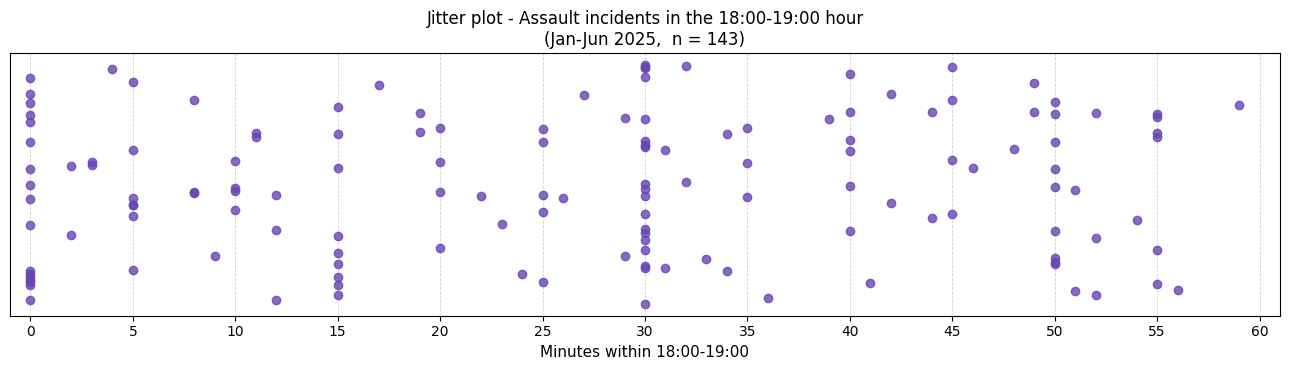

In [8]:
# Assault category is common enough that 6 months gives 100+ results, making time-recording artefacts clearly visible.

assault_df = focus_df[
    (focus_df["Unified Category"] == "Assault")
    & (focus_df["Incident Date"] >= "2025-01-01")
    & (focus_df["Incident Date"] < "2025-07-01")
]


def time_to_hours(t):
    parts = str(t).split(":")
    return int(parts[0]) + int(parts[1]) / 60


assault_df["hour_frac"] = assault_df["Incident Time"].apply(time_to_hours)
assault_df["hour"] = assault_df["hour_frac"].apply(int)

TARGET_HOUR = 18
hour_df = assault_df[assault_df["hour"] == TARGET_HOUR].copy()
hour_df["minute"] = (hour_df["hour_frac"] - TARGET_HOUR) * 60

rng = np.random.default_rng(42)
hour_df["jitter"] = rng.uniform(-0.4, 0.4, size=len(hour_df))

fig, ax = plt.subplots(figsize=(13, 3.8))
ax.scatter(hour_df["minute"], hour_df["jitter"], color="#6845b4", alpha=0.8, zorder=3)

for m in range(0, 61, 5):
    ax.axvline(m, color="lightgrey", linewidth=0.6, linestyle="--", zorder=1)

ax.set_xticks(range(0, 61, 5))
ax.set_xlim(-1, 61)
ax.set_yticks([])
ax.set_xlabel(f"Minutes within {TARGET_HOUR}:00-{TARGET_HOUR + 1}:00", fontsize=11)
ax.set_title(
    f"Jitter plot - Assault incidents in the {TARGET_HOUR}:00-{TARGET_HOUR + 1}:00 hour\n"
    f"(Jan-Jun 2025,  n = {len(hour_df)})",
    fontsize=12,
)

plt.tight_layout()
plt.show()

From the jitter plot we can see that most datapoints are clustered around the hour and half hour. Meaning most incidents in the dataset have an accuracy of ±30 minutes.

### Part B - Probability plot (Robbery & Burglary)

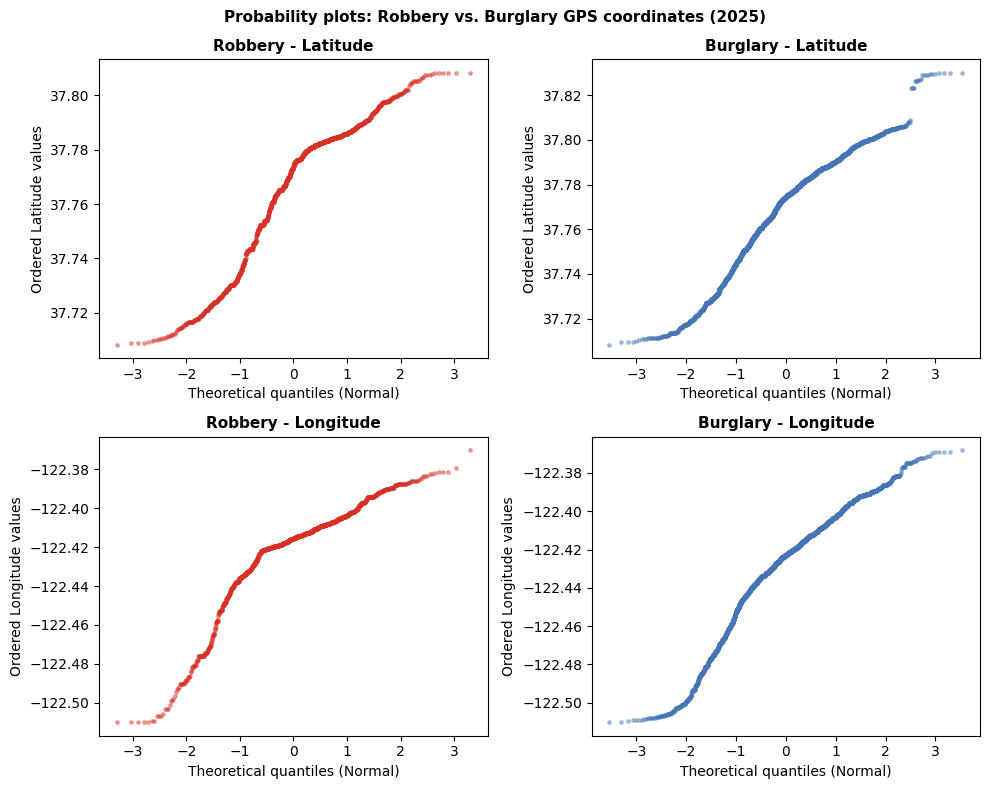

In [9]:
from scipy.stats import probplot

CATEGORIES = ["Robbery", "Burglary"]
COLORS = ["#d73027", "#4575b4"]

probablity_subset = {}
for cat in CATEGORIES:
    probablity_subset[cat] = (
        focus_df[
            (focus_df["Unified Category"] == cat)
            & (focus_df["Incident Date"] >= "2025-01-01")
            & (focus_df["Incident Date"] < "2026-01-01")
        ]
        .dropna(subset=["Latitude", "Longitude"])
        .copy()
    )

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for col, (cat, color) in enumerate(zip(CATEGORIES, COLORS)):
    for row, (coord, label) in enumerate(
        [("Latitude", "Latitude"), ("Longitude", "Longitude")]
    ):
        ax = axes[row, col]
        data = probablity_subset[cat][coord].dropna().values
        (osm, osr), _ = probplot(data, dist="norm")
        ax.scatter(osm, osr, color=color, alpha=0.4, s=6, zorder=2)
        ax.set_xlabel("Theoretical quantiles (Normal)", fontsize=10)
        ax.set_ylabel(f"Ordered {label} values", fontsize=10)
        ax.set_title(f"{cat} - {label}", fontsize=11, fontweight="bold")

fig.suptitle(
    "Probability plots: Robbery vs. Burglary GPS coordinates (2025)",
    fontsize=11,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

**Reference distribution:** The standard normal (Gaussian) distribution. Each plot compares the empirical coordinates against the quantiles we would expect if the data were perfectly normally distributed.

**If points fell exactly on the line:** The coordinate would be normally distributed, crimes would be spread symmetrically around a central point, and gradually thins toward the city's edges, with no hotspots or geographic boundaries distorting the pattern.

**Geographic interpretation:** Crime in SF is not spread like a smooth hill centred on one neighbourhood. The heavy-tailed plots reveal a clustered, reflection of SF neighbourhood contrasts, for example dense commercial neighborhoods, quiet residential districts and tourist corridors. A single normal distribution is too simple a model; the deviations expose the hotspot structure that a histogram or mean coordinate would hide.


### Part C — Box plots of time-of-day

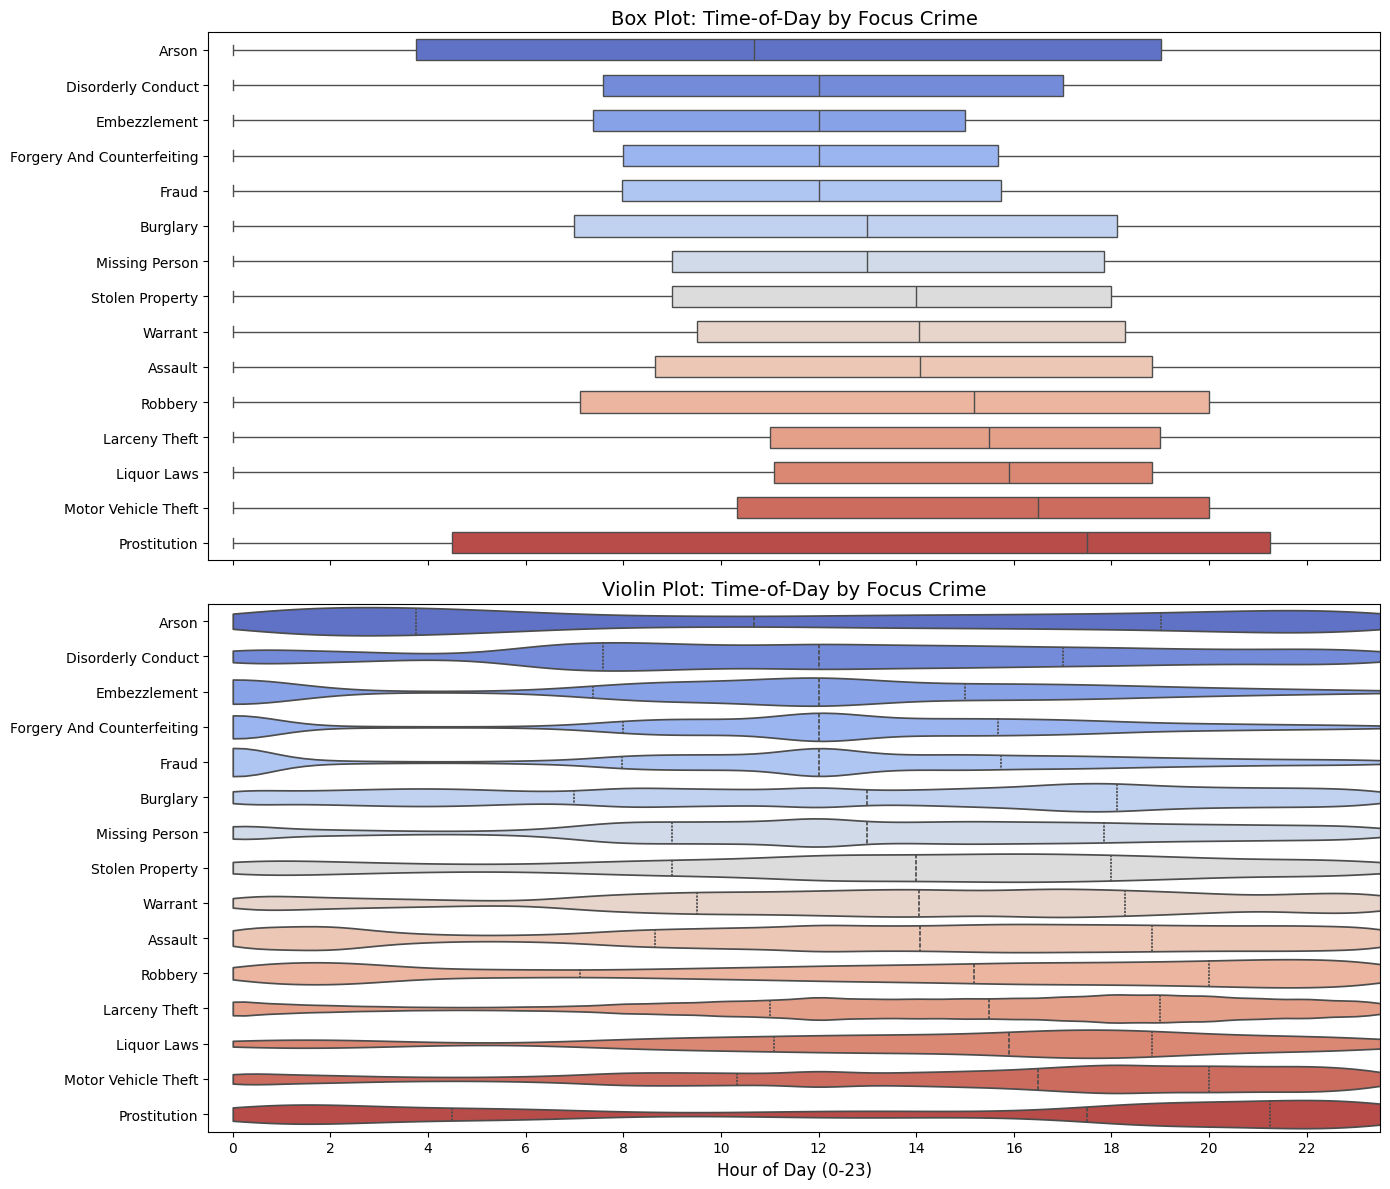

In [10]:
focus_df["Hour"] = focus_df["Incident Time"].apply(time_to_hours)
crime_order = (
    focus_df.groupby("Unified Category")["Hour"].median().sort_values().index.tolist()
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

sns.boxplot(
    data=focus_df,
    x="Hour",
    y="Unified Category",
    hue="Unified Category",
    order=crime_order,
    hue_order=crime_order,
    legend=False,
    orient="h",
    ax=ax1,
    palette="coolwarm",
    width=0.6,
    fliersize=1,
)
ax1.set_title("Box Plot: Time-of-Day by Focus Crime", fontsize=14)
ax1.set_xlabel("")
ax1.set_ylabel("")
ax1.set_xlim(-0.5, 23.5)
ax1.set_xticks(range(0, 24, 2))

sns.violinplot(
    data=focus_df,
    x="Hour",
    y="Unified Category",
    hue="Unified Category",
    order=crime_order,
    hue_order=crime_order,
    legend=False,
    orient="h",
    ax=ax2,
    palette="coolwarm",
    inner="quartile",
    cut=0,
)
ax2.set_title("Violin Plot: Time-of-Day by Focus Crime", fontsize=14)
ax2.set_xlabel("Hour of Day (0-23)", fontsize=12)
ax2.set_ylabel("")
ax2.set_xlim(-0.5, 23.5)
ax2.set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

Several clear patterns emerge from the time-of-day distributions:

**Daytime / business-hours crimes:** Fraud, Embezzlement, and Forgery And Counterfeiting cluster during working hours (roughly 8:00–17:00). This makes sense, since these are white-collar crimes tied to office hours, banking, and commercial activity. Larceny Theft also has some volume during the daytime, which for example could be shoplifting incidents.

**Evening and nighttime crimes:** Assault and Robbery shift toward the evening and night. Prostitution skews heavily toward late night and early morning hours.

**The wrap-around problem:** In our visualization we are plotting the crimes time-of-day in the 00-23 scale, which means the box plot struggles with crimes that peak around midnight. For example prostitution as an example, it's incidents cluster in both the late-night hours (22:00–23:00) and the early morning (0:00–3:00).

**Why the violin plot helps:** The violin plot reveals the full shape of each distribution, not just the five-number summary. This makes it easy to spot skewed patterns that box plots flatten. For Prostitution, you can see peaks at both ends of the 0-23 scale.

---
## Assignment 1.4: Spatial Power Law

Is crime spread evenly across San Francisco, or is it concentrated in a small number of hotspots? Let's find out.

*Draws from*: Week 4, Exercise 2.2.

Use your **most common Personal Focus Crime** (by total incident count) for this exercise.

> * **Step 1**: Divide San Francisco into a grid of approximately $100\text{m} \times 100\text{m}$ cells using latitude and longitude. It is fine to ignore that the Earth isn't flat — the approximation is good enough for this purpose.
>     * **Hint**: `np.histogram2d` works well here. Focus on points within the SF peninsula; filter out geographic outliers.
> * **Step 2**: Count the number of incidents of your chosen crime in each grid cell (use all years of data).
> * **Step 3**: Tally the distribution. Count how many cells have exactly $k$ incidents — call this $N(k)$ — for $k = 0, 1, 2, \ldots$ up to the maximum.
> * **Step 4**: Plot $(k+1)$ vs $N(k)$ on **linear axes**.
> * **Step 5**: Plot $(k+1)$ vs $N(k)$ on **loglog axes**.
> * **Step 6**: Does your crime follow a power-law spatial distribution? How can you tell from the loglog plot?
> * **Step 7**: If crime is spatially concentrated in a small number of cells, what does that imply for how we interpret neighborhood-level crime statistics? Does the "average block" tell you anything useful?

Grid dimensions: (119, 123)
Total grid squares: 14637
Grid squares with 0 thefts: 7517
Max thefts in a single grid square: 16679
Total thefts counted: 683802


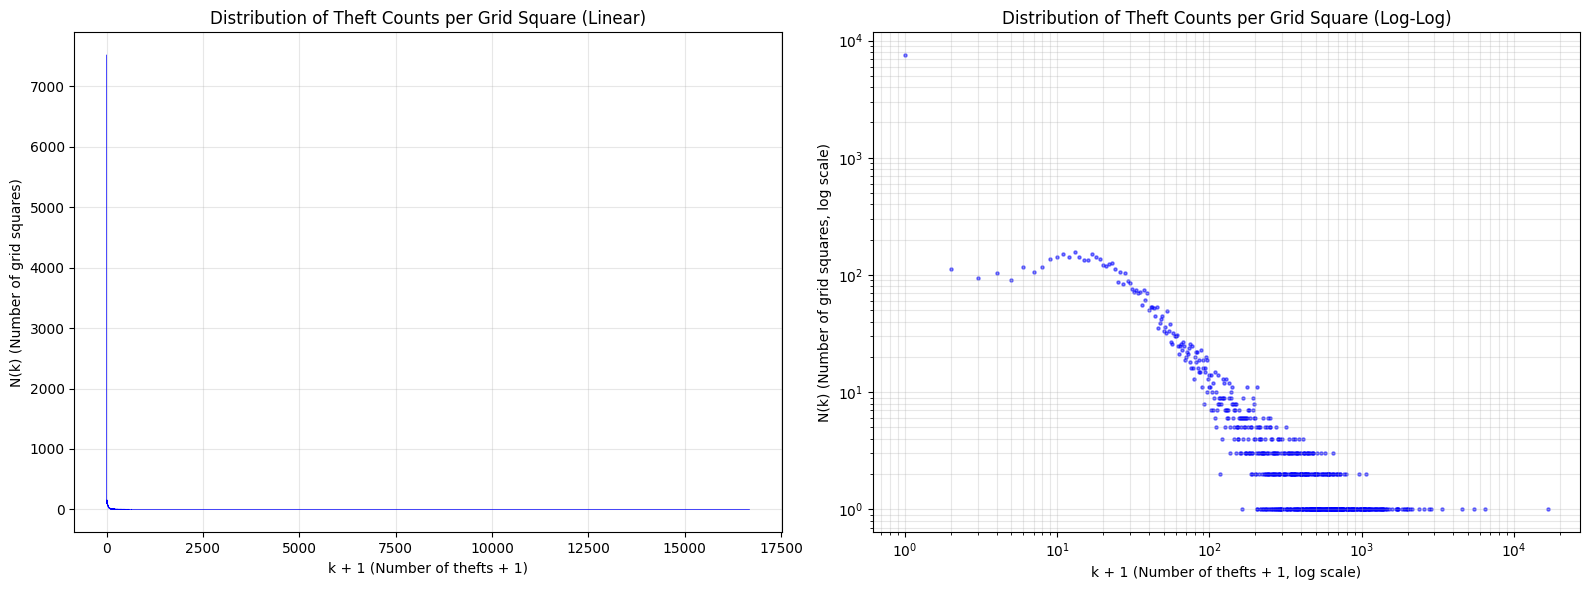

In [11]:
# Step 1: Divide SF into ~100m x 100m grid and count thefts per grid square

# Filter for theft only
theft_data = focus_df[focus_df["Unified Category"] == "Larceny Theft"].copy()
theft_data = theft_data.dropna(subset=["Latitude", "Longitude"])

# Remove outliers (keep only points on the SF peninsula)
lat_min, lat_max = 37.70, 37.82
lon_min, lon_max = -122.52, -122.36

theft_data = theft_data[
    (theft_data["Latitude"] >= lat_min)
    & (theft_data["Latitude"] <= lat_max)
    & (theft_data["Longitude"] >= lon_min)
    & (theft_data["Longitude"] <= lon_max)
]

# ~100m grid: 1 degree latitude ≈ 111km, so 100m ≈ 0.0009 degrees
# 1 degree longitude at SF latitude ≈ 85km, so 100m ≈ 0.0012 degrees
lat_bins = np.arange(lat_min, lat_max, 0.001)  # ~111m
lon_bins = np.arange(lon_min, lon_max, 0.0013)  # ~103m

# Step 2: Count thefts per grid square using histogram2d
counts, _, _ = np.histogram2d(
    theft_data["Latitude"].values,
    theft_data["Longitude"].values,
    bins=[lat_bins, lon_bins],
)

# Flatten the grid to get counts per cell
counts_flat = counts.flatten().astype(int)

print(f"Grid dimensions: {counts.shape}")
print(f"Total grid squares: {len(counts_flat)}")
print(f"Grid squares with 0 thefts: {np.sum(counts_flat == 0)}")
print(f"Max thefts in a single grid square: {counts_flat.max()}")
print(f"Total thefts counted: {counts_flat.sum()}")

# Step 3: Tally the counts — N(k) = number of grid squares with exactly k thefts
C_max = counts_flat.max()
k_values = np.arange(0, C_max + 1)
N_k = np.array([np.sum(counts_flat == k) for k in k_values])

# Step 4: Plot on linear axes
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Linear plot
axes[0].plot(k_values + 1, N_k, "b-", linewidth=0.5)
axes[0].set_xlabel("k + 1 (Number of thefts + 1)")
axes[0].set_ylabel("N(k) (Number of grid squares)")
axes[0].set_title("Distribution of Theft Counts per Grid Square (Linear)")
axes[0].grid(True, alpha=0.3)

# Step 5: Plot on loglog axes
# Filter out zero values for log plotting
mask = N_k > 0
axes[1].scatter(k_values[mask] + 1, N_k[mask], s=5, alpha=0.5, color="blue")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("k + 1 (Number of thefts + 1, log scale)")
axes[1].set_ylabel("N(k) (Number of grid squares, log scale)")
axes[1].set_title("Distribution of Theft Counts per Grid Square (Log-Log)")
axes[1].grid(True, alpha=0.3, which="both")

plt.tight_layout()
plt.show()


**Step 6: Does your crime follow a power-law spatial distribution? How can you tell from the loglog plot?**

Yes, Larceny Theft follows a power-law spatial distribution. The data points fall approximately along a straight line in the loglog plot, which is the defining signature of a power law (since log(N) = -alpha * log(k+1) + const is linear). On the linear plot, there is an L-shape, meaning an enormous number of grid squares with zero or very few thefts, and a tiny number of squares with extremely high counts (the single worst cell has over 16,000 thefts). If the distribution were uniform or even normally distributed, the loglog plot would curve rather than forming a straight line.

**Step 7: If crime is spatially concentrated in a small number of cells, what does that imply for how we interpret neighborhood-level crime statistics? Does the "average block" tell you anything useful?**

The power-law concentration has major implications for how we interpret neighborhood crime statistics. Over half of all the grid squares have zero thefts, while a tiny number of hotspots have thousands. Reporting an average crime rate per block masks this extreme skew and misleads in both directions: it overstates the risk for the vast majority of blocks that are effectively crime-free, and it dramatically understates the reality for residents and workers at the handful of hotspot locations.

For city planning, this means that blanket policing strategies spread across entire neighborhoods are inefficient — crime is not a neighborhood-level phenomenon but a micro-location phenomenon. Resources would be better targeted at the specific intersections and blocks in the tail of the distribution. For residents in those hotspot cells, the lived experience of crime is nothing like what an "average" statistic would suggest. Median-based or percentile-based measures would be far more informative than means when the distribution is this heavily skewed.

---
## Assignment 1.5: Regression and Correlation

Which of your Personal Focus Crimes share the most similar weekly rhythm — and which are completely out of sync?

*Draws from*: Week 4, Exercises 3.1, 3.2, and 3.3.

Select **at least 4** of your Personal Focus Crimes for this exercise. More is fine - if you want to be closer to the actual weekly exercise.

> * For each selected crime type, compute the total number of incidents for each of the **168 hours of the week** (i.e., Monday 00:00–01:00, Monday 01:00–02:00, ..., Sunday 23:00–00:00). Each crime type will give you a vector of 168 values.
>
> * **Scatterplot matrix**: Create a grid of pairwise scatterplots — one panel per pair of crime types, with one crime on each axis and each of the 168 hours as a point. Label each panel clearly with the two crime types being compared.
>
> * **Linear regression**: Using the closed-form equations from Week 4 (not a library), fit a regression line $y = ax + b$ to each pair and add it to the relevant panel:
>   $$a = \frac{\sum_i x_i y_i - N\langle x\rangle\langle y\rangle}{\sum_i x_i^2 - N\langle x\rangle^2}, \qquad b = \langle y \rangle - a\langle x \rangle$$
>
> * **$R^2$**: Compute $R^2$ for each pair and display the value on each panel. 
>
> * Looking at your results: which pair of crimes is **most correlated**? Which is **least correlated**? Does the answer match your intuition? Why might two crime types share a weekly rhythm — or not?

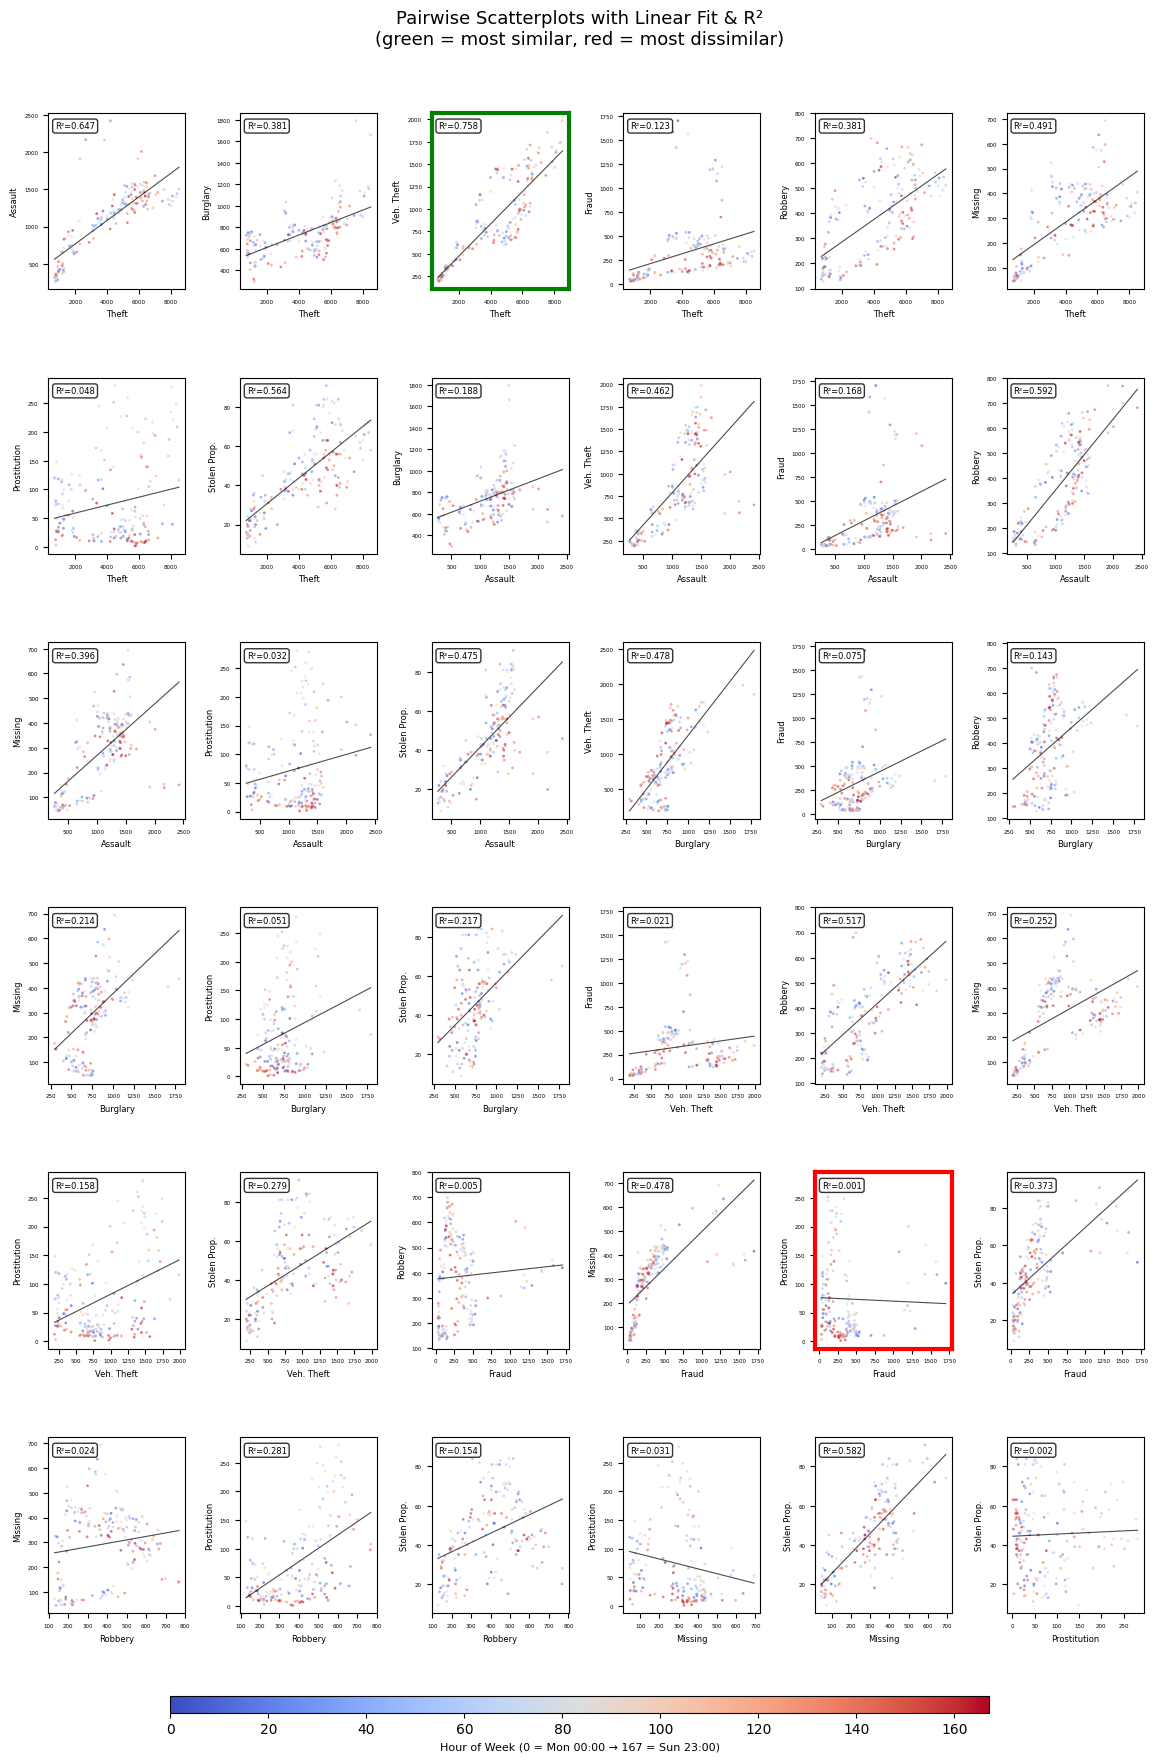

=== TOP 5 MOST CORRELATED ===
         Theft vs Veh. Theft    R² = 0.7581
         Theft vs Assault       R² = 0.6467
       Assault vs Robbery       R² = 0.5921
       Missing vs Stolen Prop.  R² = 0.5824
         Theft vs Stolen Prop.  R² = 0.5644

=== TOP 5 LEAST CORRELATED ===
       Robbery vs Missing       R² = 0.0243
    Veh. Theft vs Fraud         R² = 0.0210
         Fraud vs Robbery       R² = 0.0045
  Prostitution vs Stolen Prop.  R² = 0.0016
         Fraud vs Prostitution  R² = 0.0008

Most similar:    Theft & Veh. Theft  (R² = 0.7581)
Most dissimilar: Fraud & Prostitution  (R² = 0.0008)


In [12]:
from itertools import combinations

# --- 1. Select 9 Personal Focus Crimes (Title Case, matching focus_df) ---
selected_crimes = [
    "Larceny Theft",
    "Assault",
    "Burglary",
    "Motor Vehicle Theft",
    "Fraud",
    "Robbery",
    "Missing Person",
    "Prostitution",
    "Stolen Property",
]

short_names = {
    "Larceny Theft": "Theft",
    "Assault": "Assault",
    "Burglary": "Burglary",
    "Motor Vehicle Theft": "Veh. Theft",
    "Fraud": "Fraud",
    "Robbery": "Robbery",
    "Missing Person": "Missing",
    "Prostitution": "Prostitution",
    "Stolen Property": "Stolen Prop.",
}

# --- 2. Derive day-of-week and hour-of-week ---
# Incident Date needs to be datetime to extract weekday
focus_df["Incident Date"] = pd.to_datetime(focus_df["Incident Date"], errors="coerce")
# Monday=0 ... Sunday=6
focus_df["DayNum"] = focus_df["Incident Date"].dt.dayofweek
focus_df["Hour"] = focus_df["Incident Time"].str.split(":").str[0].astype(float)
focus_df["HourOfWeek"] = focus_df["DayNum"] * 24 + focus_df["Hour"]

# --- 3. Build 168-element vector per crime ---
hourly_data = {}
for crime in selected_crimes:
    subset = focus_df[focus_df["Unified Category"] == crime]
    counts = subset.groupby("HourOfWeek").size().reindex(range(168), fill_value=0)
    hourly_data[crime] = counts.values


# --- 4. Closed-form linear regression (Equations 1 & 2) ---
def linear_regression(x, y):
    """Return slope a and intercept b for y = ax + b."""
    N = len(x)
    x_mean, y_mean = np.mean(x), np.mean(y)
    a = (np.sum(x * y) - N * x_mean * y_mean) / (np.sum(x**2) - N * x_mean**2)
    b = y_mean - a * x_mean
    return a, b


def r_squared(x, y, a, b):
    """Coefficient of determination."""
    y_pred = a * x + b
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1 - ss_res / ss_tot


# --- 5. Compute R² for every pair ---
crime_pairs = list(combinations(selected_crimes, 2))
r2_results = {}
for c1, c2 in crime_pairs:
    x, y = hourly_data[c1].astype(float), hourly_data[c2].astype(float)
    a, b = linear_regression(x, y)
    r2_results[(c1, c2)] = r_squared(x, y, a, b)

sorted_pairs = sorted(r2_results.items(), key=lambda kv: kv[1], reverse=True)
most_sim_pair, most_sim_r2 = sorted_pairs[0]
most_dis_pair, most_dis_r2 = sorted_pairs[-1]

# --- 6. Mega-plot: 6×6 grid with scatter + fit + R² + highlights ---
hours = np.arange(168)
fig, axes = plt.subplots(6, 6, figsize=(11.69, 16.54))
fig.suptitle(
    "Pairwise Scatterplots with Linear Fit & R²\n"
    "(green = most similar, red = most dissimilar)",
    fontsize=13,
    y=1.02,
)

for idx, (c1, c2) in enumerate(crime_pairs):
    ax = axes[idx // 6, idx % 6]
    x, y = hourly_data[c1].astype(float), hourly_data[c2].astype(float)
    a, b = linear_regression(x, y)
    r2 = r2_results[(c1, c2)]

    ax.scatter(x, y, c=hours, cmap="coolwarm", s=4, alpha=0.6, edgecolors="none")
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, a * x_line + b, "k-", linewidth=0.8, alpha=0.7)
    ax.text(
        0.05,
        0.95,
        f"R²={r2:.3f}",
        transform=ax.transAxes,
        fontsize=6,
        verticalalignment="top",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
    )
    ax.set_xlabel(short_names[c1], fontsize=6)
    ax.set_ylabel(short_names[c2], fontsize=6)
    ax.tick_params(labelsize=4)

    # Highlight best / worst pair
    if (c1, c2) == most_sim_pair:
        for sp in ax.spines.values():
            sp.set_edgecolor("green")
            sp.set_linewidth(3)
    elif (c1, c2) == most_dis_pair:
        for sp in ax.spines.values():
            sp.set_edgecolor("red")
            sp.set_linewidth(3)

plt.tight_layout()
plt.subplots_adjust(hspace=0.5, wspace=0.4, bottom=0.05)
cbar_ax = fig.add_axes([0.15, -0.01, 0.7, 0.01])
sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=plt.Normalize(0, 167))
sm.set_array([])
fig.colorbar(sm, cax=cbar_ax, orientation="horizontal").set_label(
    "Hour of Week (0 = Mon 00:00 → 167 = Sun 23:00)", fontsize=8
)
plt.show()

# --- 7. Print ranked results ---
print("=== TOP 5 MOST CORRELATED ===")
for (c1, c2), r2 in sorted_pairs[:5]:
    print(f"  {short_names[c1]:>12} vs {short_names[c2]:<12}  R² = {r2:.4f}")
print("\n=== TOP 5 LEAST CORRELATED ===")
for (c1, c2), r2 in sorted_pairs[-5:]:
    print(f"  {short_names[c1]:>12} vs {short_names[c2]:<12}  R² = {r2:.4f}")
print(
    f"\nMost similar:    {short_names[most_sim_pair[0]]} & {short_names[most_sim_pair[1]]}  (R² = {most_sim_r2:.4f})"
)
print(
    f"Most dissimilar: {short_names[most_dis_pair[0]]} & {short_names[most_dis_pair[1]]}  (R² = {most_dis_r2:.4f})"
)

**Most correlated pair: Larceny Theft & Motor Vehicle Theft (R² = 0.76)**

This makes sense as both are property crimes driven by opportunity. They share the same weekly rhythm because the conditions that create opportunities for theft also create opportunities for car theft: more unattended vehicles and belongings during commuting hours and evening activities, fewer eyes on the street late at night, and a general increase in targets when people are out and about during weekdays. The correlation reflects shared context and opportunity rather than one causing the other.

**Most dissimilar pair: Fraud & Prostitution (R² ≈ 0.00)**

These crimes operate on different schedules and in completely different contexts. Fraud is overwhelmingly a daytime crime: it involves financial transactions, identity theft, and commercial interactions that happen during the day. Prostitution, by contrast, peaks during nighttime and weekend hours. Their temporal patterns are essentially independent, which is why the R² is nearly zero — knowing how many fraud reports occur in a given hour tells you nothing about how many prostitution incidents occur in that same hour.

**Why might crimes share — or not share — a weekly rhythm?**

Crimes that share a rhythm tend to be driven by the same underlying factors: foot traffic, darkness, alcohol consumption, commercial activity, or the presence/absence of potential witnesses. Assault and Robbery are both correlated with Theft because all three spike during periods of high human activity and social interaction. Crimes that don't share a rhythm are typically driven by very different mechanisms — Fraud is tied to institutional operating hours while street crimes respond to environmental conditions like lighting and crowd density.